# Fitting for an extended source polarization with `LeakageLib`

_Weights used:_
* Spatial
* Spectral

This jupyter notebook fits for the polarization of an extended source, with a photon and particle background. Here, the source is a simulated 60 arcsecond-radius uniform disk, though because of the IXPE PSF, it appears wider in the IXPE data.

The source is assumed to have constant polarization, though we provide guidance on variable polarization sources at the end.

In [1]:
import numpy as np
import leakagelib

>>> PyXSPEC is not installed, you will no be able to use it.


The first step is to load the mock Moments data. We'll center it on pixel (300, 300), and cut to 280 arcseconds around that point. See the point source fit example for a description of these functions.

In [2]:
# Load the extended source data
datas = leakagelib.IXPEData.load_all_detectors_with_path("data", "extended")

for data in datas:
    data.explicit_center(300,300)
    data.retain(data.evt_energies > 2)
    data.retain(data.evt_energies < 8)

>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...


Now we have to create a custom `Source` object to model where the source photons came from. This source object should not be blurred by the PSF; i.e. it should depict the source as seen by Chandra, not IXPE

In [3]:
pixel_size = 2.9729 # This is the size of the sky PSF pixels; use it for best results
source_pixel_edges = np.arange(0, 280+pixel_size, pixel_size)
source_pixel_edges = np.concatenate([-np.flip(source_pixel_edges)[:-1], source_pixel_edges])
# source_pixel_edges now ranges from -280 to 280, centered on zero, and spaced by `pixel_size`
source_pixel_centers = (source_pixel_edges[1:] + source_pixel_edges[:-1]) / 2

xs, ys = np.meshgrid(source_pixel_centers, source_pixel_centers)
image = (np.sqrt(xs**2 + ys**2) < 60).astype(float)

source = leakagelib.Source(image, pixel_size)

Now we give the source object to the fitter

In [4]:
settings = leakagelib.FitSettings(datas)
settings.add_source(source, "src-ext")
settings.fix_flux("src-ext", 1)
settings.set_initial_qu("src-ext", (0, 0))

The background, spectral weights, and ROI are added in the same way as the previous fits.

In [5]:
settings.add_background("bkg")
settings.set_initial_flux("bkg", 0.1)
settings.fix_qu("bkg", (0, 0))

settings.set_spectrum("bkg", lambda e: e**-2.5)
settings.set_spectrum("src-ext", lambda e: e**-1.5)

settings.apply_circular_roi(280)

>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
>>> Using cached xEffectiveArea object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
6393 events were cut for being outside the region of interest.


Let's view what the sources look like:

Data set extended DU 1 had no exposure map loaded. Please load an exposure map if you are fitting to events in the vignetted portion.


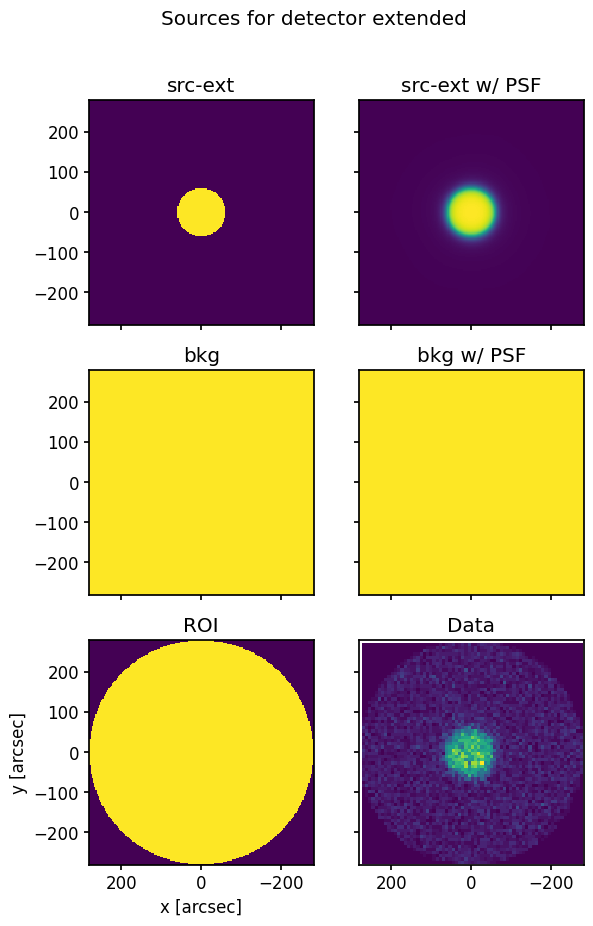

In [6]:
fitter = leakagelib.Fitter(settings)
fitter.display_sources(data_pixel_size=8);

It appears that the blurred source does indeed match the data well. If you had loaded the IXPE exposure map, the edges of the ROI would be correspondingly dimmed (although the exposure map is rather flat within 280 arcsec).

We can also view what the fitter thinks the data should look like, based on the starting parameters

/Users/jtd/Documents/research/ixpepl/code/leakagelib/src/leakagelib/ps_fit/fitter.py:197: RuntimeWarning: invalid value encountered in divide
  pred /= counts


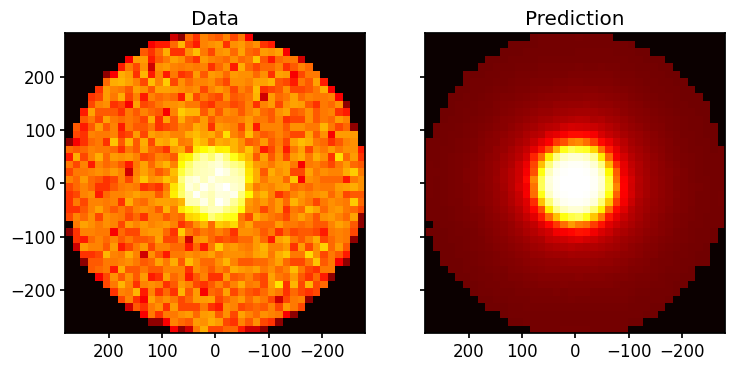

In [7]:
fitter.plot(n_bins=40);

Finally, we perform the fit

In [8]:
result = fitter.fit()
result

FitResult:
	q (src-ext) = 0.4390 +/- 0.0732
	u (src-ext) = -0.0510 +/- 0.0729
	f (bkg) = 2.1649 +/- 0.0447

Polarization:
	PD (src-ext): 0.4419 +/- 0.0732
	PA (src-ext): -3.3164 deg +/- 4.7291
Likelihood 12022.660277209434, dof 16042
Optimization terminated successfully.

The true source polarization was q=0.5, u=0, which the fit agrees with. We can also check whether the best-fit image matches the data:

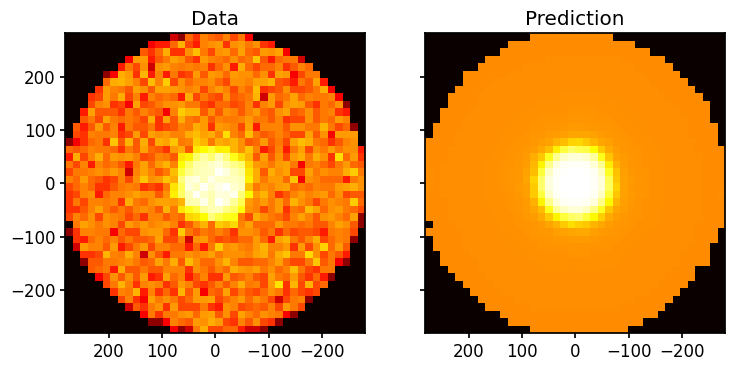

In [9]:
fitter.plot(result.best_params, n_bins=40);